In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import SplineTransformer
import numpy as np
import pandas as pd

In [1]:
import problem

X_train, y_train = problem.get_train_data()
X_test, y_test = problem.get_test_data()

In [7]:
def _encode_dates(X):
    X = X.copy()  # modify a copy of X
    # Encode the date information from the DateOfDeparture columns
    X.loc[:, "year"] = X["date"].dt.year
    X.loc[:, "month"] = X["date"].dt.month
    X.loc[:, "day"] = X["date"].dt.day
    X.loc[:, "weekday"] = X["date"].dt.weekday
    X.loc[:, "hour"] = X["date"].dt.hour

    # Finally we can drop the original columns from the dataframe
    return X.drop(columns=["date"])

In [4]:
def periodic_spline_transformer(period, n_splines=None, degree=3):
    if n_splines is None:
        n_splines = period
    n_knots = n_splines + 1  # periodic and include_bias is True
    return SplineTransformer(
        degree=degree,
        n_knots=n_knots,
        knots=np.linspace(0, period, n_knots).reshape(n_knots, 1),
        extrapolation="periodic",
        include_bias=True,
    )

In [5]:
month_spline_transformer = periodic_spline_transformer(12, n_splines=6)

In [10]:
X_train = _encode_dates(X_train)

In [15]:
X_train[['month']].shape

(455163, 1)

In [16]:
X_train['month'].shape

(455163,)

In [19]:
month_spline_col = month_spline_transformer.fit_transform(X_train[['month']])
month_spline_col

array([[0.47916667, 0.02083333, 0.        , 0.        , 0.02083333,
        0.47916667],
       [0.47916667, 0.02083333, 0.        , 0.        , 0.02083333,
        0.47916667],
       [0.47916667, 0.02083333, 0.        , 0.        , 0.02083333,
        0.47916667],
       ...,
       [0.16666667, 0.        , 0.        , 0.        , 0.16666667,
        0.66666667],
       [0.16666667, 0.        , 0.        , 0.        , 0.16666667,
        0.66666667],
       [0.16666667, 0.        , 0.        , 0.        , 0.16666667,
        0.66666667]], shape=(455163, 6))

In [20]:
month_spline_col.shape

(455163, 6)

In [35]:
month_spline_col[0].tolist()

[0.47916666666666663,
 0.020833333333333332,
 0.0,
 0.0,
 0.020833333333333332,
 0.47916666666666663]

In [37]:
X_train['month'].iloc[0]

np.int32(9)

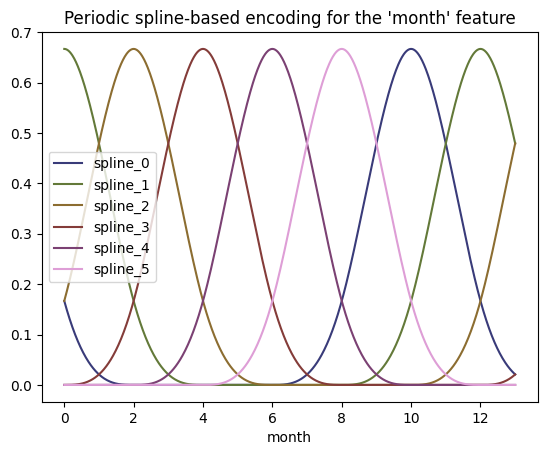

In [34]:
hour_df = pd.DataFrame(
    np.linspace(0, 13, 1000).reshape(-1, 1),
    columns=["month"],
)
splines = periodic_spline_transformer(12, n_splines=6).fit_transform(hour_df)
splines_df = pd.DataFrame(
    splines,
    columns=[f"spline_{i}" for i in range(splines.shape[1])],
)
pd.concat([hour_df, splines_df], axis="columns").plot(x="month", cmap=plt.cm.tab20b)
_ = plt.title("Periodic spline-based encoding for the 'month' feature")